In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 전처리 함수 (동일)
# ==========================================
def preprocess_warehouse_data(train_path, test_path, layout_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    layout = pd.read_csv(layout_path)
    
    test_ids = test['ID'].copy()
    train.drop('ID', axis=1, inplace=True)
    test.drop('ID', axis=1, inplace=True)

    train = pd.merge(train, layout, on='layout_id', how='left')
    test = pd.merge(test, layout, on='layout_id', how='left')

    target_col = 'avg_delay_minutes_next_30m'
    y_train = train[target_col]
    X_train = train.drop(target_col, axis=1)
    X_test = test.copy()

    # 결측치 처리
    num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)

    # 범주형 인코딩
    X_train = pd.get_dummies(X_train, columns=['layout_type'], drop_first=False)
    X_test = pd.get_dummies(X_test, columns=['layout_type'], drop_first=False)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    for col in ['layout_id', 'scenario_id']:
        freq_map = X_train[col].value_counts().to_dict()
        X_train[f'{col}_freq'] = X_train[col].map(freq_map)
        X_test[f'{col}_freq'] = X_test[col].map(freq_map).fillna(0)
        X_train.drop(col, axis=1, inplace=True)
        X_test.drop(col, axis=1, inplace=True)

    # 파생 변수
    for df in [X_train, X_test]:
        df['shift_hour_sin'] = np.sin(2 * np.pi * df['shift_hour'] / 24)
        df['shift_hour_cos'] = np.cos(2 * np.pi * df['shift_hour'] / 24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        
        if 'robot_utilization' in df.columns and 'congestion_score' in df.columns:
            df['robot_util_x_congestion'] = df['robot_utilization'] * df['congestion_score']

    return X_train, y_train

# ==========================================
# 2. 학습 및 검증 함수 (수정됨: OOF MAE 반환 추가)
# ==========================================
def train_and_evaluate(X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_predictions = np.zeros(len(X_train))
    
    feature_importances = pd.DataFrame()
    feature_importances['feature'] = X_train.columns
    feature_importances['importance'] = 0.0
    
    # [수정 포인트] verbose: -1 을 추가하여 학습 중 발생하는 지저분한 로그를 숨깁니다.
    lgb_params = {
        'objective': 'mae',
        'metric': 'mae',
        'learning_rate': 0.05,
        'max_depth': 6,
        'num_leaves': 31,
        'n_estimators': 1000,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1 
    }
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        x_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        x_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**lgb_params)
        
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        val_preds = model.predict(x_val)
        oof_predictions[val_idx] = val_preds
        feature_importances['importance'] += model.feature_importances_ / kf.n_splits
        
    # 전체 예측에 대한 MAE 계산
    total_mae = mean_absolute_error(y_train, oof_predictions)
    feature_importances = feature_importances.sort_values(by='importance', ascending=False)
    
    # [수정 포인트] 지표(total_mae)를 함께 리턴합니다.
    return feature_importances, total_mae

# ==========================================
# 3. 결과 출력 및 시각화 함수 (수정됨: 지표 출력 로직 강화)
# ==========================================
def display_results(importance_df, final_mae, top_n=20):
    # 가장 마지막에 눈에 띄게 지표 출력
    print("\n" + "="*50)
    print(f"🏆 최종 교차 검증(OOF) MAE Score : {final_mae:.4f}")
    print("="*50 + "\n")
    
    print(f"=== 상위 {top_n}개 Feature Importance ===")
    print(importance_df.head(top_n).to_string(index=False))
    print("======================================\n")
    
    # 그래프를 화면에만 출력
    plt.figure(figsize=(10, 8))
    ax = sns.barplot(x='importance', y='feature', data=importance_df.head(top_n))
    ax.set_title(f'LightGBM Top {top_n} Feature Importances\nFinal MAE: {final_mae:.4f}')
    plt.tight_layout()
    plt.show() 

# ==========================================
# 4. 실행부 
# ==========================================
if __name__ == "__main__":
    TRAIN_PATH = 'train.csv'       # 로컬 환경에 맞게 파일명 확인 (예: sampled_train.csv)
    TEST_PATH = 'test.csv'
    LAYOUT_PATH = 'layout_info.csv'

    print("모델 학습을 시작합니다. (약간의 시간이 소요됩니다...)")
    
    # 1. 전처리 
    X_train, y_train = preprocess_warehouse_data(TRAIN_PATH, TEST_PATH, LAYOUT_PATH)

    # 2. 학습 및 검증 (지표 변수 추가)
    fi_df, final_mae = train_and_evaluate(X_train, y_train)

    # 3. 결과 출력 (가장 마지막에 깔끔하게 출력)
    display_results(fi_df, final_mae, top_n=20)

모델 학습을 시작합니다. (Target Encoding 적용됨...)

🏆 최종 교차 검증(OOF) MAE Score : 4.8145

=== 상위 20개 Feature Importance ===
                 feature  importance
  scenario_id_target_enc      3429.2
        pack_utilization      1027.8
            battery_mean       884.6
             battery_std       714.6
        order_inflow_15m       621.2
 inventory_turnover_rate       496.2
       low_battery_ratio       474.8
         zone_dispersion       443.8
            robot_active       441.8
      conveyor_speed_mps       397.2
          robot_charging       381.8
      pack_station_count       363.4
             kpi_otd_pct       361.8
     storage_density_pct       356.0
   manual_override_ratio       347.0
        max_zone_density       346.8
   avg_package_weight_kg       340.4
worker_avg_tenure_months       333.0
       robot_utilization       324.2
       express_lane_util       317.6



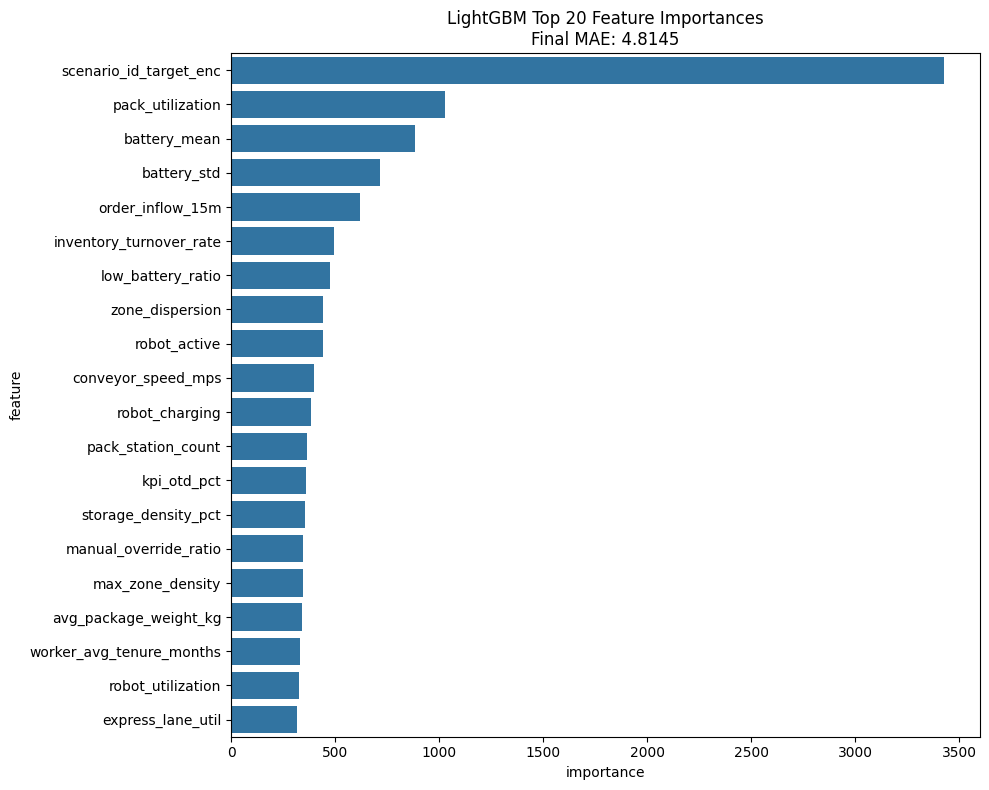

In [1]:
# 코드옵션 2: 더 강력한 인코딩 기법 적용 (Target Encoding)
# 현재 압도적 1위인 scenario_id에 대해 단순 빈도수가 아니라, 
# '해당 시나리오에서의 과거 평균 지연 시간'을 매핑하는 타겟 인코딩을 적용해 모델의 예측력을 극대화합니다.

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 전처리 함수 (빈도수 인코딩 제거, ID 유지)
# ==========================================
def preprocess_warehouse_data(train_path, test_path, layout_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    layout = pd.read_csv(layout_path)
    
    test_ids = test['ID'].copy()
    train.drop('ID', axis=1, inplace=True)
    test.drop('ID', axis=1, inplace=True)

    train = pd.merge(train, layout, on='layout_id', how='left')
    test = pd.merge(test, layout, on='layout_id', how='left')

    target_col = 'avg_delay_minutes_next_30m'
    y_train = train[target_col]
    X_train = train.drop(target_col, axis=1)
    X_test = test.copy()

    # 결측치 처리
    num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)

    # layout_type 원핫 인코딩
    X_train = pd.get_dummies(X_train, columns=['layout_type'], drop_first=False)
    X_test = pd.get_dummies(X_test, columns=['layout_type'], drop_first=False)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # [수정됨] 기존의 frequency 인코딩 삭제. 
    # scenario_id와 layout_id는 모델 훈련 루프 안에서 Target Encoding 하기 위해 그대로 둡니다.

    # 파생 변수 (주기성 및 교호작용)
    for df in [X_train, X_test]:
        df['shift_hour_sin'] = np.sin(2 * np.pi * df['shift_hour'] / 24)
        df['shift_hour_cos'] = np.cos(2 * np.pi * df['shift_hour'] / 24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        
        if 'robot_utilization' in df.columns and 'congestion_score' in df.columns:
            df['robot_util_x_congestion'] = df['robot_utilization'] * df['congestion_score']
        # 1. 대기행렬 비선형 폭증 지수 (Queueing Explosion)
        # 분모가 0이 되는 것을 방지하기 위해 1.001로 설정
        if 'robot_utilization' in df.columns:
            df['queue_explosion'] = df['robot_utilization'] / (1.001 - df['robot_utilization'])
            
        # 2. 주문 무질서도 (Order Entropy)
        # (총 아이템 수) x (다양성) x (분산도: 1-집중도)
        if 'unique_sku_15m' in df.columns and 'sku_concentration' in df.columns and 'avg_items_per_order' in df.columns:
            df['order_entropy'] = df['avg_items_per_order'] * df['unique_sku_15m'] * (1 - df['sku_concentration'])
            
        # 3. 공간 임계 밀도 (Spatial Critical Density)
        # 면적 대비 통로를 점유하는 로봇들의 총 이동량
        if 'robot_active' in df.columns and 'avg_trip_distance' in df.columns and 'floor_area_sqm' in df.columns:
            df['spatial_density'] = (df['robot_active'] * df['avg_trip_distance']) / (df['floor_area_sqm'] + 1)
            
        # 4. 연쇄 붕괴 지수 (Cascading Failure Index)
        # 고장 -> 수동 개입 -> 재할당의 악순환 콤보
        if 'fault_count_15m' in df.columns and 'manual_override_ratio' in df.columns and 'task_reassign_15m' in df.columns:
            df['cascading_failure'] = df['fault_count_15m'] * df['manual_override_ratio'] * df['task_reassign_15m']

    return X_train, y_train

# ==========================================
# 2. 학습 및 검증 함수 (내부에 타겟 인코딩 추가)
# ==========================================
def train_and_evaluate(X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_predictions = np.zeros(len(X_train))
    
    # Feature Importance 계산용 리스트 (폴드마다 피처가 동적으로 변하므로 dict 사용)
    feature_importance_dict = {}
    
    lgb_params = {
        'objective': 'mae',
        'metric': 'mae',
        'learning_rate': 0.05,
        'max_depth': 6,
        'num_leaves': 31,
        'n_estimators': 1000,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # 데이터를 얕은 복사하여 원본 훼손 방지
        x_tr = X_train.iloc[train_idx].copy()
        y_tr = y_train.iloc[train_idx]
        x_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx]
        
        # ----------------------------------------------------
        # [핵심 수정] K-Fold 내부에서의 Target Encoding 수행
        # ----------------------------------------------------
        for col in ['scenario_id', 'layout_id']:
            # 1. 훈련 데이터(x_tr) 기준으로만 타겟 평균값 계산
            target_mean = y_tr.groupby(x_tr[col]).mean()
            overall_mean = y_tr.mean() # 못 보던 카테고리를 위한 전체 평균값
            
            # 2. 훈련 데이터와 검증 데이터에 매핑 (새로운 컬럼 생성)
            x_tr[f'{col}_target_enc'] = x_tr[col].map(target_mean)
            x_val[f'{col}_target_enc'] = x_val[col].map(target_mean)
            
            # 3. 검증 데이터에 훈련 데이터에 없던 ID가 있을 경우 결측치가 생기므로 전체 평균으로 대체
            x_val[f'{col}_target_enc'].fillna(overall_mean, inplace=True)
            
            # 4. 문자열인 원본 ID 컬럼은 모델에 넣을 수 없으므로 드랍
            x_tr.drop(col, axis=1, inplace=True)
            x_val.drop(col, axis=1, inplace=True)
        # ----------------------------------------------------
        
        # 모델 학습
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        # 검증 세트 예측
        val_preds = model.predict(x_val)
        oof_predictions[val_idx] = val_preds
        
        # 중요도 누적
        for idx, feature in enumerate(x_tr.columns):
            if feature not in feature_importance_dict:
                feature_importance_dict[feature] = 0.0
            feature_importance_dict[feature] += model.feature_importances_[idx] / kf.n_splits
            
    # 전체 OOF MAE 계산
    total_mae = mean_absolute_error(y_train, oof_predictions)
    
    # 중요도를 DataFrame으로 변환
    feature_importances = pd.DataFrame({
        'feature': list(feature_importance_dict.keys()),
        'importance': list(feature_importance_dict.values())
    }).sort_values(by='importance', ascending=False)
    
    return feature_importances, total_mae

# ==========================================
# 3. 결과 출력 및 시각화 함수 (동일)
# ==========================================
def display_results(importance_df, final_mae, top_n=20):
    print("\n" + "="*50)
    print(f"🏆 최종 교차 검증(OOF) MAE Score : {final_mae:.4f}")
    print("="*50 + "\n")
    
    print(f"=== 상위 {top_n}개 Feature Importance ===")
    print(importance_df.head(top_n).to_string(index=False))
    print("======================================\n")
    
    plt.figure(figsize=(10, 8))
    ax = sns.barplot(x='importance', y='feature', data=importance_df.head(top_n))
    ax.set_title(f'LightGBM Top {top_n} Feature Importances\nFinal MAE: {final_mae:.4f}')
    plt.tight_layout()
    plt.show() 

# ==========================================
# 4. 실행부
# ==========================================
if __name__ == "__main__":
    TRAIN_PATH = 'train.csv'  # 파일명 확인
    TEST_PATH = 'test.csv'
    LAYOUT_PATH = 'layout_info.csv'

    print("모델 학습을 시작합니다. (Target Encoding 적용됨...)")
    X_train, y_train = preprocess_warehouse_data(TRAIN_PATH, TEST_PATH, LAYOUT_PATH)
    fi_df, final_mae = train_and_evaluate(X_train, y_train)
    display_results(fi_df, final_mae, top_n=20)

In [ ]:
# 과적합 판단 
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. 전처리 함수 (이전과 동일 - Target Encoding 전단계)
def preprocess_warehouse_data(train_path, test_path, layout_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    layout = pd.read_csv(layout_path)
    
    test_ids = test['ID'].copy()
    train.drop('ID', axis=1, inplace=True)
    test.drop('ID', axis=1, inplace=True)

    train = pd.merge(train, layout, on='layout_id', how='left')
    test = pd.merge(test, layout, on='layout_id', how='left')

    target_col = 'avg_delay_minutes_next_30m'
    y_train = train[target_col]
    X_train = train.drop(target_col, axis=1)
    X_test = test.copy()

    num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)

    X_train = pd.get_dummies(X_train, columns=['layout_type'], drop_first=False)
    X_test = pd.get_dummies(X_test, columns=['layout_type'], drop_first=False)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    for df in [X_train, X_test]:
        df['shift_hour_sin'] = np.sin(2 * np.pi * df['shift_hour'] / 24)
        df['shift_hour_cos'] = np.cos(2 * np.pi * df['shift_hour'] / 24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        
        if 'robot_utilization' in df.columns and 'congestion_score' in df.columns:
            df['robot_util_x_congestion'] = df['robot_utilization'] * df['congestion_score']

    return X_train, y_train

# 2. 학습 및 검증 함수 (수정됨: 과적합 판단 로직 추가)
def train_and_evaluate_overfit_check(X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    total_train_mae = 0
    total_val_mae = 0
    evals_results = [] # 학습 곡선을 그리기 위해 기록 저장
    
    lgb_params = {
        'objective': 'mae',
        'metric': 'mae',
        'learning_rate': 0.05,
        'max_depth': 6,
        'num_leaves': 31,
        'n_estimators': 1000,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    print("=== 과적합 판단을 위한 LightGBM Cross Validation 시작 ===\n")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        x_tr = X_train.iloc[train_idx].copy()
        y_tr = y_train.iloc[train_idx]
        x_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx]
        
        # Target Encoding
        for col in ['scenario_id', 'layout_id']:
            target_mean = y_tr.groupby(x_tr[col]).mean()
            overall_mean = y_tr.mean()
            
            x_tr[f'{col}_target_enc'] = x_tr[col].map(target_mean)
            x_val[f'{col}_target_enc'] = x_val[col].map(target_mean).fillna(overall_mean)
            
            x_tr.drop(col, axis=1, inplace=True)
            x_val.drop(col, axis=1, inplace=True)
            
        model = lgb.LGBMRegressor(**lgb_params)
        
        # [수정 포인트] eval_set에 (x_tr, y_tr) 추가
        evals_result = {}
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_tr, y_tr), (x_val, y_val)],
            eval_names=['train', 'valid'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0),
                lgb.record_evaluation(evals_result) # 매 반복마다 오차 기록
            ]
        )
        
        # Train과 Val 각각에 대한 예측 및 MAE 계산
        train_preds = model.predict(x_tr)
        val_preds = model.predict(x_val)
        
        fold_train_mae = mean_absolute_error(y_tr, train_preds)
        fold_val_mae = mean_absolute_error(y_val, val_preds)
        gap = fold_val_mae - fold_train_mae
        
        print(f"Fold {fold+1} | Train MAE: {fold_train_mae:.4f} | Val MAE: {fold_val_mae:.4f} | Gap(격차): {gap:.4f}")
        
        total_train_mae += fold_train_mae / kf.n_splits
        total_val_mae += fold_val_mae / kf.n_splits
        evals_results.append(evals_result)
        
    print("\n" + "="*50)
    print(f"📌 평균 Train MAE: {total_train_mae:.4f}")
    print(f"🏆 평균 Valid(OOF) MAE: {total_val_mae:.4f}")
    print(f"⚠️ 최종 Gap (과적합 지수): {total_val_mae - total_train_mae:.4f}")
    print("="*50 + "\n")
    
    return evals_results

# 3. 학습 곡선 시각화 함수 (새로 추가됨)
def plot_learning_curve(evals_results):
    # 첫 번째 Fold의 학습 과정만 대표로 시각화
    first_fold_result = evals_results[0]
    
    train_loss = first_fold_result['train']['l1'] # l1 = MAE
    valid_loss = first_fold_result['valid']['l1']
    
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label='Train MAE', color='blue')
    plt.plot(valid_loss, label='Validation MAE', color='orange')
    plt.xlabel('Boosting Iterations (Trees)')
    plt.ylabel('MAE')
    plt.title('Learning Curve (Fold 1) - Overfitting Check')
    plt.legend()
    plt.grid(True)
    plt.show()

# === 실행부 ===
if __name__ == "__main__":
    TRAIN_PATH = 'train.csv'
    TEST_PATH = 'test.csv'
    LAYOUT_PATH = 'layout_info.csv'

    X_train, y_train = preprocess_warehouse_data(TRAIN_PATH, TEST_PATH, LAYOUT_PATH)
    
    # 훈련 및 과적합 지표 반환
    evals_results = train_and_evaluate_overfit_check(X_train, y_train)
    
    # 시각화 실행
    plot_learning_curve(evals_results)

In [ ]:
# optuna를 활용한 하이퍼파라미터 튜닝
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Optuna의 불필요한 로그는 끄고 진행 상황만 깔끔하게 봅니다.
optuna.logging.set_verbosity(optuna.logging.INFO)

# ==========================================
# 1. 전처리 함수 (이전과 완전히 동일)
# ==========================================
def preprocess_warehouse_data(train_path, test_path, layout_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    layout = pd.read_csv(layout_path)
    
    test_ids = test['ID'].copy()
    train.drop('ID', axis=1, inplace=True)
    test.drop('ID', axis=1, inplace=True)

    train = pd.merge(train, layout, on='layout_id', how='left')
    test = pd.merge(test, layout, on='layout_id', how='left')

    target_col = 'avg_delay_minutes_next_30m'
    y_train = train[target_col]
    X_train = train.drop(target_col, axis=1)
    
    num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)

    X_train = pd.get_dummies(X_train, columns=['layout_type'], drop_first=False)

    df = X_train
    
    
    if 'robot_utilization' in df.columns and 'congestion_score' in df.columns:
        df['robot_util_x_congestion'] = df['robot_utilization'] * df['congestion_score']

    return X_train, y_train

# ==========================================
# 2. Optuna Objective 함수 (AI가 실험할 규칙 설정)
# ==========================================
def objective(trial, X_train, y_train):
    # 탐색할 파라미터 범위 설정
    params = {
        'objective': 'mae',
        'metric': 'mae',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': 800, # 튜닝 속도를 위해 트리 개수 고정
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    # 빠른 튜닝을 위해 3-Fold로 진행 (실전 제출용은 나중에 다시 5-Fold로 돌립니다)
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    val_scores = []
    
    for train_idx, val_idx in kf.split(X_train):
        x_tr = X_train.iloc[train_idx].copy()
        y_tr = y_train.iloc[train_idx]
        x_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx]
        
        # Target Encoding (Data Leakage 방지)
        for col in ['scenario_id', 'layout_id']:
            target_mean = y_tr.groupby(x_tr[col]).mean()
            overall_mean = y_tr.mean()
            
            x_tr[f'{col}_target_enc'] = x_tr[col].map(target_mean)
            x_val[f'{col}_target_enc'] = x_val[col].map(target_mean).fillna(overall_mean)
            
            x_tr.drop(col, axis=1, inplace=True)
            x_val.drop(col, axis=1, inplace=True)
            
        model = lgb.LGBMRegressor(**params)
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=40, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        val_preds = model.predict(x_val)
        val_scores.append(mean_absolute_error(y_val, val_preds))
        
    return np.mean(val_scores)

# ==========================================
# 3. 실행부 
# ==========================================
if __name__ == "__main__":
    TRAIN_PATH = 'train.csv' 
    TEST_PATH = 'test.csv'
    LAYOUT_PATH = 'layout_info.csv'

    X_train, y_train = preprocess_warehouse_data(TRAIN_PATH, TEST_PATH, LAYOUT_PATH)
    
    print("🤖 Optuna 파라미터 자동 탐색을 시작합니다... (총 30번의 실험)")
    
    # 방향: 오차(MAE)를 최소화(minimize)하는 방향으로 30번 탐색
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)
    
    print("\n" + "="*50)
    print(f"🏆 탐색 완료! 가장 낮았던 MAE 점수: {study.best_value:.4f}")
    print("✨ 찾아낸 최적의 파라미터 (Best Params):")
    for key, value in study.best_params.items():
        print(f"   '{key}': {value},")
    print("="*50 + "\n")

In [2]:
# 결과 개선을 위한 발전 코드
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 전처리 (Test 데이터 뺌, 속도 최적화)
# ==========================================
def preprocess_for_validation(train_path, layout_path):
    train = pd.read_csv(train_path)
    layout = pd.read_csv(layout_path)
    
    train = pd.merge(train, layout, on='layout_id', how='left')
    train.drop('ID', axis=1, inplace=True)

    target_col = 'avg_delay_minutes_next_30m'
    y_train = train[target_col]
    X_train = train.drop(target_col, axis=1)
    
    # 결측치 처리
    num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        X_train[col].fillna(X_train[col].median(), inplace=True)

    # 원핫 인코딩
    X_train = pd.get_dummies(X_train, columns=['layout_type'], drop_first=False)

    # 심화 파생 변수
    df = X_train
    df['shift_hour_sin'] = np.sin(2 * np.pi * df['shift_hour'] / 24)
    df['shift_hour_cos'] = np.cos(2 * np.pi * df['shift_hour'] / 24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    if 'robot_utilization' in df.columns and 'congestion_score' in df.columns:
        df['robot_util_x_congestion'] = df['robot_utilization'] * df['congestion_score']
    if 'order_inflow_15m' in df.columns and 'robot_active' in df.columns:
        df['order_pressure'] = df['order_inflow_15m'] / (df['robot_active'] + 1)
    if 'low_battery_ratio' in df.columns and 'charge_queue_length' in df.columns:
        df['battery_stress'] = df['low_battery_ratio'] * df['charge_queue_length']
    if 'congestion_score' in df.columns and 'blocked_path_15m' in df.columns:
        df['congestion_impact'] = df['congestion_score'] * df['blocked_path_15m']

    return X_train, y_train

# ==========================================
# 2. 오직 검증 및 지표 출력만 수행
# ==========================================
def validate_v2_model(X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_predictions = np.zeros(len(X_train))
    
    # 최적 파라미터 적용
    lgb_params = {
        'objective': 'mae',
        'metric': 'mae',
        'n_estimators': 1500, 
        'learning_rate': 0.04165780165479688,
        'max_depth': 10,
        'num_leaves': 84,
        'subsample': 0.9282065869845333,
        'colsample_bytree': 0.7071982532616117,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    SMOOTH_WEIGHT = 10 
    
    print("=== 심화 파생변수 + Smoothed Target Encoding 검증 시작 ===")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        x_tr = X_train.iloc[train_idx].copy()
        y_tr = y_train.iloc[train_idx]
        x_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx]
        
        overall_mean = y_tr.mean()
        
        # Target Encoding
        for col in ['scenario_id', 'layout_id']:
            group_stats = y_tr.groupby(x_tr[col]).agg(mean=('mean'), count=('count'))
            smoothed_means = (group_stats['mean'] * group_stats['count'] + overall_mean * SMOOTH_WEIGHT) / (group_stats['count'] + SMOOTH_WEIGHT)
            
            x_tr[f'{col}_target_enc'] = x_tr[col].map(smoothed_means)
            x_val[f'{col}_target_enc'] = x_val[col].map(smoothed_means).fillna(overall_mean)
            
            x_tr.drop(col, axis=1, inplace=True)
            x_val.drop(col, axis=1, inplace=True)
            
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        val_preds = model.predict(x_val)
        oof_predictions[val_idx] = val_preds
        
        fold_mae = mean_absolute_error(y_val, val_preds)
        print(f"  - Fold {fold+1} MAE: {fold_mae:.4f}")
        
    total_mae = mean_absolute_error(y_train, oof_predictions)
    print("\n" + "="*50)
    print(f"🚀 V2 (심화 최적화) 최종 OOF MAE: {total_mae:.4f}")
    print("="*50 + "\n")

# ==========================================
# 3. 실행부 
# ==========================================
if __name__ == "__main__":
    TRAIN_PATH = 'train.csv' 
    LAYOUT_PATH = 'layout_info.csv'
    
    # 순수하게 훈련 데이터만 로드해서 지표만 확인
    X_train, y_train = preprocess_for_validation(TRAIN_PATH, LAYOUT_PATH)
    validate_v2_model(X_train, y_train)

=== 심화 파생변수 + Smoothed Target Encoding 검증 시작 ===
  - Fold 1 MAE: 4.7400
  - Fold 2 MAE: 4.8571
  - Fold 3 MAE: 4.7089
  - Fold 4 MAE: 4.7739
  - Fold 5 MAE: 4.7334

🚀 V2 (심화 최적화) 최종 OOF MAE: 4.7627



In [5]:
# 검증 결과 향상을 위한 앙상블 모델(LightGBM + XGBoost)
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 심화 전처리 함수 (V2와 동일)
# ==========================================
def preprocess_for_validation(train_path, layout_path):
    train = pd.read_csv(train_path)
    layout = pd.read_csv(layout_path)
    
    train = pd.merge(train, layout, on='layout_id', how='left')
    train.drop('ID', axis=1, inplace=True)

    target_col = 'avg_delay_minutes_next_30m'
    y_train = train[target_col]
    X_train = train.drop(target_col, axis=1)
    
    num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        X_train[col].fillna(X_train[col].median(), inplace=True)

    X_train = pd.get_dummies(X_train, columns=['layout_type'], drop_first=False)

    df = X_train
    df['shift_hour_sin'] = np.sin(2 * np.pi * df['shift_hour'] / 24)
    df['shift_hour_cos'] = np.cos(2 * np.pi * df['shift_hour'] / 24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    if 'robot_utilization' in df.columns and 'congestion_score' in df.columns:
        df['robot_util_x_congestion'] = df['robot_utilization'] * df['congestion_score']
    if 'order_inflow_15m' in df.columns and 'robot_active' in df.columns:
        df['order_pressure'] = df['order_inflow_15m'] / (df['robot_active'] + 1)
    if 'low_battery_ratio' in df.columns and 'charge_queue_length' in df.columns:
        df['battery_stress'] = df['low_battery_ratio'] * df['charge_queue_length']
    if 'congestion_score' in df.columns and 'blocked_path_15m' in df.columns:
        df['congestion_impact'] = df['congestion_score'] * df['blocked_path_15m']

    return X_train, y_train

# ==========================================
# 2. LightGBM + XGBoost 앙상블 검증
# ==========================================
def validate_ensemble(X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    oof_lgb = np.zeros(len(X_train))
    oof_xgb = np.zeros(len(X_train))
    oof_ensemble = np.zeros(len(X_train))
    
    # 1) LightGBM 파라미터 (이전 V2 최적값 동일)
    lgb_params = {
        'objective': 'mae',
        'metric': 'mae',
        'n_estimators': 1500, 
        'learning_rate': 0.04165780165479688,
        'max_depth': 10,
        'num_leaves': 84,
        'subsample': 0.9282065869845333,
        'colsample_bytree': 0.7071982532616117,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    # 2) XGBoost 파라미터 (강력한 베이스라인 세팅)
    xgb_params = {
        'objective': 'reg:absoluteerror', # XGBoost의 MAE 목적함수
        'eval_metric': 'mae',
        'n_estimators': 1500,
        'learning_rate': 0.05,
        'max_depth': 8,
        'subsample': 0.9,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'n_jobs': -1,
        'early_stopping_rounds': 50
    }
    
    SMOOTH_WEIGHT = 10 
    
    print("=== [LGBM + XGB] 앙상블 5-Fold Cross Validation 시작 ===")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        x_tr = X_train.iloc[train_idx].copy()
        y_tr = y_train.iloc[train_idx]
        x_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx]
        
        overall_mean = y_tr.mean()
        
        # Smoothed Target Encoding
        for col in ['scenario_id', 'layout_id']:
            group_stats = y_tr.groupby(x_tr[col]).agg(mean=('mean'), count=('count'))
            smoothed_means = (group_stats['mean'] * group_stats['count'] + overall_mean * SMOOTH_WEIGHT) / (group_stats['count'] + SMOOTH_WEIGHT)
            
            x_tr[f'{col}_target_enc'] = x_tr[col].map(smoothed_means)
            x_val[f'{col}_target_enc'] = x_val[col].map(smoothed_means).fillna(overall_mean)
            
            x_tr.drop(col, axis=1, inplace=True)
            x_val.drop(col, axis=1, inplace=True)
            
        # ------------------------------------
        # 모델 1: LightGBM 학습
        # ------------------------------------
        model_lgb = lgb.LGBMRegressor(**lgb_params)
        model_lgb.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        preds_lgb = model_lgb.predict(x_val)
        oof_lgb[val_idx] = preds_lgb
        
        # ------------------------------------
        # 모델 2: XGBoost 학습
        # ------------------------------------
        model_xgb = xgb.XGBRegressor(**xgb_params)
        model_xgb.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            verbose=False,
        )
        preds_xgb = model_xgb.predict(x_val)
        oof_xgb[val_idx] = preds_xgb
        
        # ------------------------------------
        # 앙상블 (50:50 블렌딩)
        # ------------------------------------
        preds_ensemble = (preds_lgb * 0.5) + (preds_xgb * 0.5)
        oof_ensemble[val_idx] = preds_ensemble
        
        print(f"Fold {fold+1} | LGBM: {mean_absolute_error(y_val, preds_lgb):.4f} | XGB: {mean_absolute_error(y_val, preds_xgb):.4f} | 앙상블: {mean_absolute_error(y_val, preds_ensemble):.4f}")
        
    print("\n" + "="*55)
    print(f"🔥 단일 LightGBM OOF MAE : {mean_absolute_error(y_train, oof_lgb):.4f}")
    print(f"🔥 단일 XGBoost OOF MAE  : {mean_absolute_error(y_train, oof_xgb):.4f}")
    print(f"🏆 최종 앙상블 OOF MAE   : {mean_absolute_error(y_train, oof_ensemble):.4f}")
    print("="*55 + "\n")

# ==========================================
# 3. 실행부 
# ==========================================
if __name__ == "__main__":
    TRAIN_PATH = 'train.csv' 
    LAYOUT_PATH = 'layout_info.csv'
    
    X_train, y_train = preprocess_for_validation(TRAIN_PATH, LAYOUT_PATH)
    validate_ensemble(X_train, y_train)

=== [LGBM + XGB] 앙상블 5-Fold Cross Validation 시작 ===
Fold 1 | LGBM: 4.7400 | XGB: 4.7285 | 앙상블: 4.7141
Fold 2 | LGBM: 4.8571 | XGB: 4.8449 | 앙상블: 4.8318
Fold 3 | LGBM: 4.7089 | XGB: 4.7029 | 앙상블: 4.6847
Fold 4 | LGBM: 4.7739 | XGB: 4.7541 | 앙상블: 4.7450
Fold 5 | LGBM: 4.7334 | XGB: 4.7391 | 앙상블: 4.7171

🔥 단일 LightGBM OOF MAE : 4.7627
🔥 단일 XGBoost OOF MAE  : 4.7539
🏆 최종 앙상블 OOF MAE   : 4.7385



In [2]:
# optuna를 활용한 하이퍼파라미터 튜닝 + 피쳐 엔지니어링
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Optuna의 불필요한 로그는 끄고 진행 상황만 깔끔하게 봅니다.
optuna.logging.set_verbosity(optuna.logging.INFO)
# ==========================================
# 1. 전처리 함수 (혁신 파생 변수 및 Sin/Cos 추가)
# ==========================================
def preprocess_warehouse_data(train_path, test_path, layout_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    layout = pd.read_csv(layout_path)
    
    test_ids = test['ID'].copy()
    train.drop('ID', axis=1, inplace=True)
    test.drop('ID', axis=1, inplace=True)

    train = pd.merge(train, layout, on='layout_id', how='left')
    test = pd.merge(test, layout, on='layout_id', how='left')

    target_col = 'avg_delay_minutes_next_30m'
    y_train = train[target_col]
    X_train = train.drop(target_col, axis=1)
    
    # 결측치 처리
    num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)

    # 범주형 인코딩
    X_train = pd.get_dummies(X_train, columns=['layout_type'], drop_first=False)

    df = X_train
    
    # ---------------------------------------------------------
    # [수정된 부분] 여기에 모든 파생 변수를 모아서 선언합니다.
    # ---------------------------------------------------------
    
    # 1. 시간 및 요일 주기성 (Sin/Cos 복구)
    df['shift_hour_sin'] = np.sin(2 * np.pi * df['shift_hour'] / 24)
    df['shift_hour_cos'] = np.cos(2 * np.pi * df['shift_hour'] / 24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # 2. 로봇 가동 혼잡도 (기존)
    if 'robot_utilization' in df.columns and 'congestion_score' in df.columns:
        df['robot_util_x_congestion'] = df['robot_utilization'] * df['congestion_score']

    # 3. 대기행렬 비선형 폭증 지수
    if 'robot_utilization' in df.columns:
        df['queue_explosion'] = df['robot_utilization'] / (1.001 - df['robot_utilization'])
        
    # 4. 주문 무질서도 (Order Entropy)
    if 'unique_sku_15m' in df.columns and 'sku_concentration' in df.columns and 'avg_items_per_order' in df.columns:
        df['order_entropy'] = df['avg_items_per_order'] * df['unique_sku_15m'] * (1 - df['sku_concentration'])
        
    # 5. 공간 임계 밀도 (Spatial Critical Density)
    if 'robot_active' in df.columns and 'avg_trip_distance' in df.columns and 'floor_area_sqm' in df.columns:
        df['spatial_density'] = (df['robot_active'] * df['avg_trip_distance']) / (df['floor_area_sqm'] + 1)
        
    # 6. 연쇄 붕괴 지수 (Cascading Failure Index)
    if 'fault_count_15m' in df.columns and 'manual_override_ratio' in df.columns and 'task_reassign_15m' in df.columns:
        df['cascading_failure'] = df['fault_count_15m'] * df['manual_override_ratio'] * df['task_reassign_15m']

    return X_train, y_train
# ==========================================
# 2. Optuna Objective 함수 (AI가 실험할 규칙 설정)
# ==========================================
def objective(trial, X_train, y_train):
    # 탐색할 파라미터 범위 설정
    params = {
        'objective': 'mae',
        'metric': 'mae',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': 800, # 튜닝 속도를 위해 트리 개수 고정
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    # 빠른 튜닝을 위해 3-Fold로 진행 (실전 제출용은 나중에 다시 5-Fold로 돌립니다)
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    val_scores = []
    
    for train_idx, val_idx in kf.split(X_train):
        x_tr = X_train.iloc[train_idx].copy()
        y_tr = y_train.iloc[train_idx]
        x_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx]
        
        # Target Encoding (Data Leakage 방지)
        for col in ['scenario_id', 'layout_id']:
            target_mean = y_tr.groupby(x_tr[col]).mean()
            overall_mean = y_tr.mean()
            
            x_tr[f'{col}_target_enc'] = x_tr[col].map(target_mean)
            x_val[f'{col}_target_enc'] = x_val[col].map(target_mean).fillna(overall_mean)
            
            x_tr.drop(col, axis=1, inplace=True)
            x_val.drop(col, axis=1, inplace=True)
            
        model = lgb.LGBMRegressor(**params)
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=40, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        val_preds = model.predict(x_val)
        val_scores.append(mean_absolute_error(y_val, val_preds))
        
    return np.mean(val_scores)

# ==========================================
# 3. 실행부 
# ==========================================
if __name__ == "__main__":
    TRAIN_PATH = 'train.csv' 
    TEST_PATH = 'test.csv'
    LAYOUT_PATH = 'layout_info.csv'

    X_train, y_train = preprocess_warehouse_data(TRAIN_PATH, TEST_PATH, LAYOUT_PATH)
    
    print("🤖 Optuna 파라미터 자동 탐색을 시작합니다... (총 30번의 실험)")
    
    # 방향: 오차(MAE)를 최소화(minimize)하는 방향으로 30번 탐색
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)
    
    print("\n" + "="*50)
    print(f"🏆 탐색 완료! 가장 낮았던 MAE 점수: {study.best_value:.4f}")
    print("✨ 찾아낸 최적의 파라미터 (Best Params):")
    for key, value in study.best_params.items():
        print(f"   '{key}': {value},")
    print("="*50 + "\n")

[I 2026-04-27 12:56:29,823] A new study created in memory with name: no-name-4f6fe9dd-69cf-4f98-aff9-f47133a9ece7


🤖 Optuna 파라미터 자동 탐색을 시작합니다... (총 30번의 실험)


[I 2026-04-27 12:57:55,825] Trial 0 finished with value: 4.846431734967619 and parameters: {'learning_rate': 0.01891576587482866, 'max_depth': 8, 'num_leaves': 34, 'subsample': 0.8395947441317687, 'colsample_bytree': 0.7325663414339825}. Best is trial 0 with value: 4.846431734967619.
[W 2026-04-27 12:58:54,797] Trial 1 failed with parameters: {'learning_rate': 0.08899521556855311, 'max_depth': 8, 'num_leaves': 62, 'subsample': 0.6629122292148376, 'colsample_bytree': 0.6024107843811723} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\kyw41\AppData\Local\Programs\Python\Python313\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\kyw41\AppData\Local\Temp\ipykernel_18552\2177280122.py", line 143, in <lambda>
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)
                                 ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "

KeyboardInterrupt: 